# Deep Learning Project - USO Oil ETF Price Prediction using ANN
**Topics:** ANN, Forward Pass, Backpropagation, Adam Optimizer, RMSProp, Sigmoid, Tanh, ReLU, Naive Bayes

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## 1. Load & Explore Data

In [6]:
df = pd.read_csv(r'C:\Users\S\OneDrive - Higher Education Commission\Desktop\USO-Price-Prediction-ANN\oilprice.csv')
print('Shape:', df.shape)
print('Missing:', df.isnull().sum().sum())
df.head()

Shape: (1718, 81)
Missing: 0


,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1718.0,1.273234e+02,1.752699e+01,1.009200e+02,1.162200e+02,1.219150e+02,1.284275e+02,1.732000e+02
High,1718.0,1.278542e+02,1.763119e+01,1.009900e+02,1.165400e+02,1.223250e+02,1.290875e+02,1.740700e+02
Low,1718.0,1.267777e+02,1.739651e+01,1.002300e+02,1.157400e+02,1.213700e+02,1.278400e+02,1.729200e+02
Close,1718.0,1.273195e+02,1.753627e+01,1.005000e+02,1.160525e+02,1.217950e+02,1.284700e+02,1.736100e+02
Adj Close,1718.0,1.273195e+02,1.753627e+01,1.005000e+02,1.160525e+02,1.217950e+02,1.284700e+02,1.736100e+02
...,...,...,...,...,...,...,...,...
USO_High,1718.0,2.230715e+01,1.147867e+01,8.030000e+00,1.150000e+01,1.663500e+01,3.466750e+01,4.230000e+01
USO_Low,1718.0,2.190466e+01,1.137400e+01,7.670000e+00,1.130000e+01,1.604000e+01,3.411000e+01,4.130000e+01
USO_Close,1718.0,2.210905e+01,1.143279e+01,7.960000e+00,1.139250e+01,1.634500e+01,3.441750e+01,4.201000e+01
USO_Adj Close,1718.0,2.210905e+01,1.143279e+01,7.960000e+00,1.139250e+01,1.634500e+01,3.441750e+01,4.201000e+01


## 2. Feature Engineering & Preprocessing

In [8]:
# Features: Gold ETF prices, major indices, commodities, currencies
features = [
    'High', 'Low', 'Open', 'Volume',        # Gold ETF
    'SP_open', 'SP_close', 'SP_high',        # S&P 500
    'DJ_open', 'DJ_close',                   # Dow Jones
    'EG_close', 'EU_Price',                  # Emerging markets & Euro
    'OF_Price', 'OS_Price',                  # Oil futures
    'SF_Price', 'PLT_Price', 'PLD_Price',    # Silver, Platinum, Palladium
    'RHO_PRICE', 'USDI_Price',               # Rhodium, USD Index
    'GDX_Close', 'GDX_Volume',               # Gold miners ETF
    'USO_Open', 'USO_High', 'USO_Low', 'USO_Volume'  # USO other OHLCV
]

target = 'USO_Close'

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_tr = torch.FloatTensor(X_train_s)
y_tr = torch.FloatTensor(y_train).unsqueeze(1)
X_te = torch.FloatTensor(X_test_s)
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

print(f'Train: {len(X_train)}, Test: {len(X_test)}, Features: {X_train.shape[1]}')

Train: 1374, Test: 344, Features: 24


## 3. ANN Model (Forward Pass + Backpropagation)

In [9]:
class PriceANN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):          # Forward Pass
        return self.net(x)

def train(model, optimizer, loader, epochs=50):
    criterion = nn.MSELoss()
    losses = []
    for ep in range(epochs):
        model.train()
        total = 0
        for xb, yb in loader:
            pred = model(xb)             # Forward pass
            loss = criterion(pred, yb)
            optimizer.zero_grad()         # Clear gradients
            loss.backward()               # Backpropagation
            optimizer.step()              # Update weights
            total += loss.item()
        losses.append(total / len(loader))
        if (ep+1) % 10 == 0:
            print(f'  Epoch {ep+1}/{epochs} | Loss: {losses[-1]:.4f}')
    return losses

n = X_train.shape[1]

## 4. Activation Functions (Sigmoid, Tanh, ReLU)

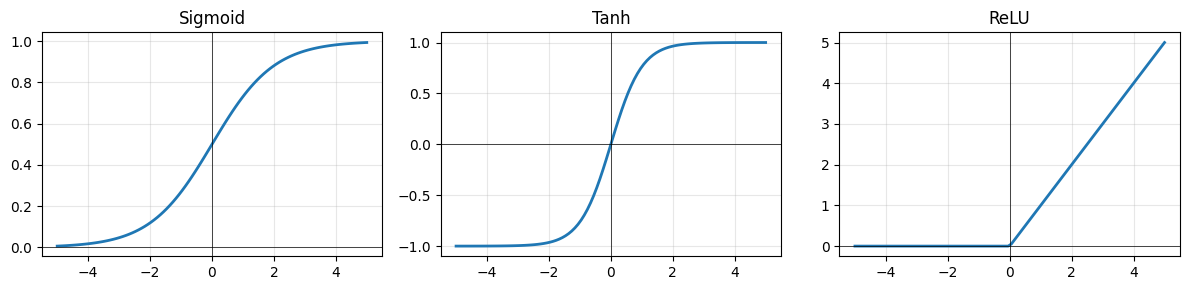

In [10]:
x = torch.linspace(-5, 5, 100)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, d, t in zip(ax, [torch.sigmoid(x), torch.tanh(x), torch.relu(x)],
                       ['Sigmoid', 'Tanh', 'ReLU']):
    a.plot(x.numpy(), d.numpy(), lw=2); a.set_title(t)
    a.grid(True, alpha=0.3); a.axhline(0, color='k', lw=0.5); a.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

## 5. Train with RMSProp & Adam Optimizers

=== RMSProp ===
  Epoch 10/50 | Loss: 7.9605
  Epoch 20/50 | Loss: 6.7866
  Epoch 30/50 | Loss: 6.0176
  Epoch 40/50 | Loss: 5.5494
  Epoch 50/50 | Loss: 5.0310

=== Adam ===
  Epoch 10/50 | Loss: 14.4253
  Epoch 20/50 | Loss: 8.5202
  Epoch 30/50 | Loss: 6.4690
  Epoch 40/50 | Loss: 5.5809
  Epoch 50/50 | Loss: 5.1968


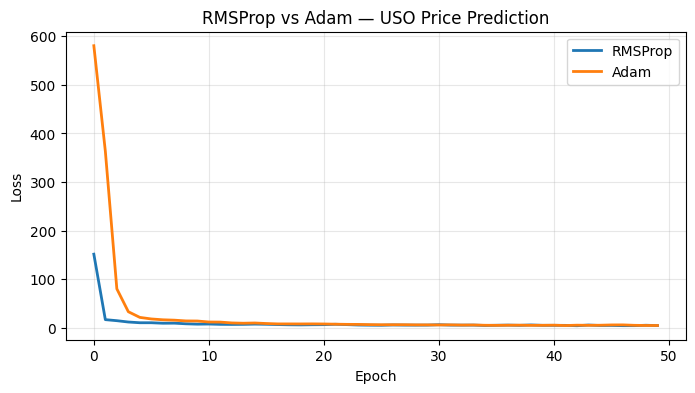

In [11]:
print('=== RMSProp ===')
m1 = PriceANN(n)
l1 = train(m1, torch.optim.RMSprop(m1.parameters(), lr=0.001), loader)

print('\n=== Adam ===')
m2 = PriceANN(n)
l2 = train(m2, torch.optim.Adam(m2.parameters(), lr=0.001), loader)

plt.figure(figsize=(8, 4))
plt.plot(l1, label='RMSProp', lw=2)
plt.plot(l2, label='Adam', lw=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('RMSProp vs Adam — USO Price Prediction'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 6. Evaluate Model

R2:   0.9952
RMSE: 0.8018
MAE:  0.6327

ML project (Linear Regression) R2 was 0.7405 -- DL ANN R2 is 0.9952


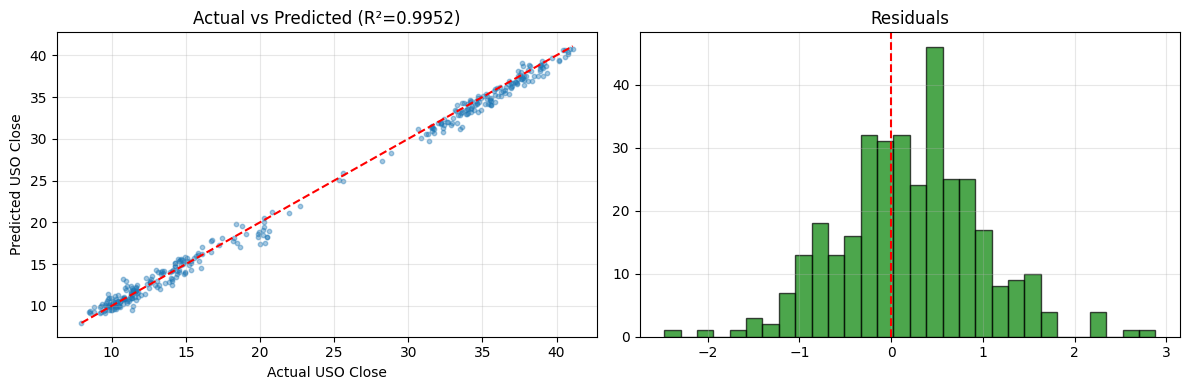

In [12]:
m2.eval()
with torch.no_grad():
    y_pred = m2(X_te).numpy().flatten()

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f'R2:   {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'\nML project (Linear Regression) R2 was 0.7405 -- DL ANN R2 is {r2:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test, y_pred, alpha=0.4, s=10)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_xlabel('Actual USO Close'); ax[0].set_ylabel('Predicted USO Close')
ax[0].set_title(f'Actual vs Predicted (R²={r2:.4f})'); ax[0].grid(True, alpha=0.3)
ax[1].hist(y_test - y_pred, bins=30, color='green', alpha=0.7, edgecolor='black')
ax[1].set_title('Residuals'); ax[1].axvline(0, color='r', ls='--'); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Naive Bayes (Classification)

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Bin USO_Close into Low / Medium / High using dataset percentiles
p33 = np.percentile(y, 33)
p66 = np.percentile(y, 66)
def label(v): return 'Low' if v < p33 else ('Medium' if v < p66 else 'High')

yc_tr = np.array([label(v) for v in y_train])
yc_te = np.array([label(v) for v in y_test])

nb = GaussianNB()
nb.fit(X_train_s, yc_tr)
nb_pred = nb.predict(X_test_s)

print(f'Accuracy: {accuracy_score(yc_te, nb_pred):.4f}')
print(classification_report(yc_te, nb_pred))

Accuracy: 0.9419
              precision    recall  f1-score   support

        High       0.88      1.00      0.94       124
         Low       0.99      0.98      0.99       103
      Medium       0.98      0.85      0.91       117

    accuracy                           0.94       344
   macro avg       0.95      0.94      0.94       344
weighted avg       0.95      0.94      0.94       344



## 8. Save Model

In [14]:
torch.save({
    'model_state': m2.state_dict(),
    'input_dim': n,
    'feature_names': features,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'r2_score': r2,
    'rmse': rmse,
    'mae': mae
}, 'uso_ann_model.pth')
print('Saved uso_ann_model.pth')

Saved uso_ann_model.pth


---
## 9. Flask Web App
Run this cell then open **http://127.0.0.1:5000**

In [ ]:
from flask import Flask, request, jsonify, send_file
import threading, torch, numpy as np, torch.nn as nn

class PriceANN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1))
    def forward(self, x): return self.net(x)

ckpt = torch.load('uso_ann_model.pth', map_location='cpu', weights_only=False)
model = PriceANN(ckpt['input_dim'])
model.load_state_dict(ckpt['model_state'])
model.eval()
s_mean  = np.array(ckpt['scaler_mean'])
s_scale = np.array(ckpt['scaler_scale'])

app = Flask(__name__)

@app.route('/')
def home():
    return send_file('index.html')

@app.route('/api/predict', methods=['POST'])
def predict():
    d = request.json
    f = np.array([[
        float(d['high']), float(d['low']), float(d['open']), float(d['volume']),
        float(d['sp_open']), float(d['sp_close']), float(d['sp_high']),
        float(d['dj_open']), float(d['dj_close']),
        float(d['eg_close']), float(d['eu_price']),
        float(d['of_price']), float(d['os_price']),
        float(d['sf_price']), float(d['plt_price']), float(d['pld_price']),
        float(d['rho_price']), float(d['usdi_price']),
        float(d['gdx_close']), float(d['gdx_volume']),
        float(d['uso_open']), float(d['uso_high']), float(d['uso_low']), float(d['uso_volume'])
    ]])
    f = (f - s_mean) / s_scale
    with torch.no_grad():
        pred = model(torch.FloatTensor(f)).item()
    return jsonify({
        'predicted_uso_close': round(pred, 2),
        'model_r2': round(ckpt['r2_score'], 4),
        'model_rmse': round(ckpt['rmse'], 2)
    })

threading.Thread(target=lambda: app.run(port=5000, use_reloader=False), daemon=True).start()
print('Server running! Open: http://127.0.0.1:5000')

Server running! Open: http://127.0.0.1:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [25/May/2026 13:05:34] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [25/May/2026 13:05:35] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [25/May/2026 13:13:33] "POST /api/predict HTTP/1.1" 200 -
